# New-Gen Blind Rank-1 Analysis

This notebook explores blind rank-1 signatures from `rank1_blind_detection`.

Focus:
- intrinsic per-layer rank-1 structure
- proj-vs-fc contrast where available
- local-window anomaly curves

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (16, 5), 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'notebooks' / 'new-gen' / '_newgen_utils.py').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'notebooks' / 'new-gen'))
from _newgen_utils import (
    latest_structural_runs,
    select_run_files,
    load_experiment_df,
    load_json,
    flatten_metric_table,
    collect_detection_predictions,
    aggregate_sweep_outcomes,
)

In [2]:
model_filter = ['gpt2-large', 'gpt2-xl', 'qwen3-4b']
use_sweep_aware = True

selection = 'latest_model_sweep' if use_sweep_aware else 'latest_model'
all_run_files = latest_structural_runs(
    ROOT,
    max_files=500,
    model_substrings=model_filter,
    include_outputs=True,
    recursive=True,
)
run_files = select_run_files(all_run_files, selection=selection)

payloads = [load_json(p) for p in run_files]
print(f'Loaded {len(payloads)} run files (selection={selection})')
for p in run_files:
    print(' -', p.name)

Loaded 33 run files (selection=latest_model_sweep)
 - rome_structural_qwen3-4b_tk96_tf2_tl2_nl1_rw5_lw3-5-7_s08_r01_2026-03-29_11-30-47.json
 - rome_structural_qwen3-4b_tk64_tf2_tl2_nl1_rw5_lw3-5-7_s07_r01_2026-03-29_04-12-22.json
 - rome_structural_qwen3-4b_tk48_tf2_tl2_nl1_rw5_lw3-5-7_s06_r01_2026-03-28_19-52-35.json
 - rome_structural_qwen3-4b_tk32_tf2_tl2_nl1_rw5_lw3-5-7_s05_r01_2026-03-28_12-33-47.json
 - rome_structural_qwen3-4b_tk16_tf2_tl2_nl1_rw5_lw3-5-7_s04_r01_2026-03-28_05-13-48.json
 - rome_structural_qwen3-4b_tk8_tf2_tl2_nl1_rw5_lw3-5-7_s03_r01_2026-03-27_21-55-04.json
 - rome_structural_qwen3-4b_tk6_tf2_tl2_nl1_rw5_lw3-5-7_s02_r01_2026-03-27_14-37-36.json
 - rome_structural_qwen3-4b_tk4_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-27_07-25-43.json
 - rome_structural_gpt2-xl_tk96_tf2_tl2_nl1_rw5_lw3-5-7_s08_r01_2026-03-27_02-59-08.json
 - rome_structural_gpt2-xl_tk64_tf2_tl2_nl1_rw5_lw3-5-7_s07_r01_2026-03-26_22-32-48.json
 - rome_structural_gpt2-xl_tk48_tf2_tl2_nl1_rw5_lw3-5-

## Sweep/Top-K Outcome Snapshot

This section summarizes run-level detector rates, shows run-to-run jumps, and aggregates outcomes for local windows and spectral top-k.

In [3]:
summary_df = load_experiment_df(
    root=ROOT,
    max_files=500,
    model_substrings=model_filter,
    selection='all',
    include_rate_jumps=True,
    include_outputs=True,
    recursive=True,
)

if summary_df.empty:
    print('No structural run summaries found for selected model filter.')
else:
    base_cols = [
        'model', 'sweep_slug', 'file', 'run_ordinal', 'run_index',
        'spectral_top_k', 'trim_first', 'trim_last', 'spectral_neighbor_layers',
        'spectral_rolling_window', 'local_windows', 'n_tests', 'successful', 'total',
        'rank1_blind_rate', 'composite_rate', 'spectral_rate', 'presence_rate',
    ]
    base_cols = [c for c in base_cols if c in summary_df.columns]
    display(summary_df[base_cols].sort_values(['model', 'sweep_slug', 'file']).tail(60))

    latest = (
        summary_df.sort_values(['model', 'sweep_slug', 'file_mtime', 'run_ordinal', 'run_index', 'file'])
        .groupby(['model', 'sweep_slug'], as_index=False)
        .tail(1)
)

    jump_cols = [
        'rank1_blind_rate_jump', 'composite_rate_jump', 'spectral_rate_jump', 'presence_rate_jump',
    ]
    jump_cols = [c for c in jump_cols if c in latest.columns]
    show_cols = [
        'model', 'sweep_slug', 'file', 'n_tests', 'successful', 'total',
        'rank1_blind_rate', 'composite_rate', 'spectral_rate', 'presence_rate',
    ] + jump_cols
    show_cols = [c for c in show_cols if c in latest.columns]

    print('Latest per (model, sweep) with jumps')
    display(latest[show_cols].sort_values(['model', 'sweep_slug']))

    # Aggregate local-window outcomes across all runs.
    lw_src = summary_df[summary_df['local_windows'].notna()].copy()
    lw_outcome = aggregate_sweep_outcomes(lw_src, by=('model', 'local_windows'))
    if not lw_outcome.empty:
        print('Local-window outcome (mean detector rates across runs)')
        lw_priority = [c for c in ('composite_rate', 'spectral_rate', 'rank1_blind_rate', 'presence_rate') if c in lw_outcome.columns]
        if lw_priority:
            lw_rank = lw_outcome.sort_values(['model', *lw_priority], ascending=[True] + [False] * len(lw_priority), na_position='last')
        else:
            lw_rank = lw_outcome.sort_values(['model', 'local_windows'])
        display(lw_rank)

    # Aggregate top-k outcomes across all runs.
    topk_src = summary_df[summary_df['spectral_top_k'].notna()].copy()
    topk_outcome = aggregate_sweep_outcomes(topk_src, by=('model', 'spectral_top_k'))
    if not topk_outcome.empty:
        print('Spectral top-k outcome (mean detector rates across runs)')
        topk_priority = [c for c in ('composite_rate', 'spectral_rate', 'rank1_blind_rate', 'presence_rate') if c in topk_outcome.columns]
        if topk_priority:
            topk_rank = topk_outcome.sort_values(['model', *topk_priority], ascending=[True] + [False] * len(topk_priority), na_position='last')
        else:
            topk_rank = topk_outcome.sort_values(['model', 'spectral_top_k'])
        display(topk_rank)

,model,sweep_slug,file,run_ordinal,run_index,spectral_top_k,trim_first,trim_last,spectral_neighbor_layers,spectral_rolling_window,local_windows,n_tests,successful,total,rank1_blind_rate,composite_rate,spectral_rate,presence_rate
40,gpt2-large,single,rome_structural_gpt2-large_2026-03-23_14-31-56...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,1.000000,1.000000,1.0
37,gpt2-large,single,rome_structural_gpt2-large_2026-03-24_01-20-36...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100,100,100,NaN,0.620000,0.600000,1.0
20,gpt2-large,tk16_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk16_tf2_tl2_nl1_rw...,4.0,1.0,16.0,2.0,2.0,1.0,5.0,3-5-7,100,100,100,0.010000,0.580000,0.580000,0.0
19,gpt2-large,tk32_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk32_tf2_tl2_nl1_rw...,5.0,1.0,32.0,2.0,2.0,1.0,5.0,3-5-7,100,100,100,0.010000,0.620000,0.610000,0.0
18,gpt2-large,tk48_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk48_tf2_tl2_nl1_rw...,6.0,1.0,48.0,2.0,2.0,1.0,5.0,3-5-7,100,100,100,0.010000,0.640000,0.640000,0.0
23,gpt2-large,tk4_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk4_tf2_tl2_nl1_rw5...,1.0,1.0,4.0,2.0,2.0,1.0,5.0,3-5-7,100,100,100,0.010000,0.070000,0.400000,0.0
35,gpt2-large,tk50_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,1.0,1.0,50.0,2.0,2.0,1.0,5.0,3-5-7,3,3,3,0.000000,0.666667,0.666667,1.0
29,gpt2-large,tk50_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,1.0,1.0,50.0,2.0,2.0,1.0,5.0,3-5-7,3,3,3,0.000000,0.666667,0.666667,1.0
17,gpt2-large,tk64_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk64_tf2_tl2_nl1_rw...,7.0,1.0,64.0,2.0,2.0,1.0,5.0,3-5-7,100,100,100,0.010000,0.640000,0.630000,0.0
34,gpt2-large,tk64_tf3_tl3_nl2_rw9_lw5-9-13,rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw...,2.0,1.0,64.0,3.0,3.0,2.0,9.0,5-9-13,3,3,3,0.000000,0.000000,0.000000,1.0


Latest per (model, sweep) with jumps


,model,sweep_slug,file,n_tests,successful,total,rank1_blind_rate,composite_rate,spectral_rate,presence_rate,rank1_blind_rate_jump,composite_rate_jump,spectral_rate_jump,presence_rate_jump
37,gpt2-large,single,rome_structural_gpt2-large_2026-03-24_01-20-36...,100,100,100,NaN,0.620000,0.600000,1.0,NaN,-0.380000,-0.400000,0.0
20,gpt2-large,tk16_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk16_tf2_tl2_nl1_rw...,100,100,100,0.01,0.580000,0.580000,0.0,NaN,NaN,NaN,NaN
19,gpt2-large,tk32_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk32_tf2_tl2_nl1_rw...,100,100,100,0.01,0.620000,0.610000,0.0,NaN,NaN,NaN,NaN
18,gpt2-large,tk48_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk48_tf2_tl2_nl1_rw...,100,100,100,0.01,0.640000,0.640000,0.0,NaN,NaN,NaN,NaN
23,gpt2-large,tk4_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk4_tf2_tl2_nl1_rw5...,100,100,100,0.01,0.070000,0.400000,0.0,NaN,NaN,NaN,NaN
29,gpt2-large,tk50_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw...,3,3,3,0.00,0.666667,0.666667,1.0,0.000000,0.000000,0.000000,0.0
17,gpt2-large,tk64_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk64_tf2_tl2_nl1_rw...,100,100,100,0.01,0.640000,0.630000,0.0,NaN,NaN,NaN,NaN
28,gpt2-large,tk64_tf3_tl3_nl2_rw9_lw5-9-13,rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw...,3,3,3,0.00,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.0
22,gpt2-large,tk6_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk6_tf2_tl2_nl1_rw5...,100,100,100,0.01,0.060000,0.410000,0.0,NaN,NaN,NaN,NaN
21,gpt2-large,tk8_tf2_tl2_nl1_rw5_lw3-5-7,rome_structural_gpt2-large_tk8_tf2_tl2_nl1_rw5...,100,100,100,0.01,0.120000,0.470000,0.0,NaN,NaN,NaN,NaN


Local-window outcome (mean detector rates across runs)


,model,local_windows,runs,total_tests,successful,rome_rate,blind_rate,spectral_rate,composite_rate,rank1_blind_rate,attention_rate,symmetry_rate,ipr_rate,presence_rate
0,gpt2-large,3-5-7,10,806,806,0.970000,0.008,0.575333,0.410333,0.008000,0.008,0.008,0.0,0.2
1,gpt2-large,5-9-13,2,6,6,0.833333,0.000,0.000000,0.000000,0.000000,0.000,0.000,0.0,1.0
2,gpt2-xl,3-5-7,10,806,806,0.970000,0.008,0.029000,0.523000,0.008000,0.008,0.008,0.0,0.2
3,gpt2-xl,5-9-13,2,6,6,0.833333,0.000,0.000000,0.333333,0.000000,0.000,0.000,0.0,1.0
4,qwen3-4b,3-5-7,10,806,806,0.974000,0.000,0.000000,0.451667,0.861000,0.000,0.000,0.0,0.2
5,qwen3-4b,5-9-13,2,6,6,1.000000,0.000,0.166667,0.166667,0.666667,0.000,0.000,0.0,1.0


Spectral top-k outcome (mean detector rates across runs)


,model,spectral_top_k,runs,total_tests,successful,rome_rate,blind_rate,spectral_rate,composite_rate,rank1_blind_rate,attention_rate,symmetry_rate,ipr_rate,presence_rate
6,gpt2-large,50.0,2,6,6,1.000000,0.000000,0.666667,0.666667,0.000000,0.000000,0.000000,0.0,1.000000
5,gpt2-large,48.0,1,100,100,0.960000,0.010000,0.640000,0.640000,0.010000,0.010000,0.010000,0.0,0.000000
4,gpt2-large,32.0,1,100,100,0.960000,0.010000,0.610000,0.620000,0.010000,0.010000,0.010000,0.0,0.000000
3,gpt2-large,16.0,1,100,100,0.960000,0.010000,0.580000,0.580000,0.010000,0.010000,0.010000,0.0,0.000000
7,gpt2-large,64.0,3,106,106,0.878889,0.003333,0.210000,0.213333,0.003333,0.003333,0.003333,0.0,0.666667
2,gpt2-large,8.0,1,100,100,0.960000,0.010000,0.470000,0.120000,0.010000,0.010000,0.010000,0.0,0.000000
0,gpt2-large,4.0,1,100,100,0.960000,0.010000,0.400000,0.070000,0.010000,0.010000,0.010000,0.0,0.000000
1,gpt2-large,6.0,1,100,100,0.960000,0.010000,0.410000,0.060000,0.010000,0.010000,0.010000,0.0,0.000000
8,gpt2-large,96.0,1,100,100,0.970000,0.010000,0.680000,0.040000,0.010000,0.010000,0.010000,0.0,0.000000
15,gpt2-xl,50.0,2,6,6,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0,1.000000


In [4]:
metric_paths = {
    'combined_score': ('combined_score',),
    'raw_rank_score': ('raw_rank_score',),
    'top1_energy': ('proj_series', 'top1_energy'),
    'gap12': ('proj_series', 'gap12'),
    'rank1_residual': ('proj_series', 'rank1_residual'),
    'stable_rank': ('proj_series', 'stable_rank'),
    'top1_abs_gap': ('contrast_series', 'top1_energy_abs_gap'),
    'gap12_abs_gap': ('contrast_series', 'gap12_abs_gap'),
    'raw_local_max': ('local_window_scores', 'raw_rank', 'max_local_rank'),
}

frames = []
for payload in payloads:
    df = flatten_metric_table(payload, detection_key='rank1_blind', metric_paths=metric_paths)
    if not df.empty:
        frames.append(df)

rank1_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
rank1_df.head()

,source,case_id,model,layer,value,target_layer,metric
0,test,73,Qwen/Qwen3-4B,0,0.728551,12.0,combined_score
1,test,73,Qwen/Qwen3-4B,1,0.904041,12.0,combined_score
2,test,73,Qwen/Qwen3-4B,2,0.807163,12.0,combined_score
3,test,73,Qwen/Qwen3-4B,3,0.716347,12.0,combined_score
4,test,73,Qwen/Qwen3-4B,4,0.656673,12.0,combined_score


In [5]:
if rank1_df.empty:
    print('No rank1_blind detection data found.')
else:
    summary = (rank1_df[rank1_df['source'] == 'test']
               .groupby(['model', 'metric'])['value']
               .agg(['count', 'mean', 'std'])
               .reset_index())
    display(summary)

,model,metric,count,mean,std
0,Qwen/Qwen3-4B,combined_score,29016,0.603389,0.133356
1,Qwen/Qwen3-4B,gap12,29016,1.320159,0.344700
2,Qwen/Qwen3-4B,gap12_abs_gap,29016,0.225766,0.266795
3,Qwen/Qwen3-4B,rank1_residual,29016,0.994020,0.007842
4,Qwen/Qwen3-4B,raw_local_max,29016,0.686022,0.229020
5,Qwen/Qwen3-4B,raw_rank_score,29016,0.500000,0.202961
6,Qwen/Qwen3-4B,stable_rank,29016,266.212647,113.288905
7,Qwen/Qwen3-4B,top1_abs_gap,29016,0.003583,0.007016
8,Qwen/Qwen3-4B,top1_energy,29016,0.005980,0.007842
9,gpt2-large,combined_score,29016,0.591551,0.101965


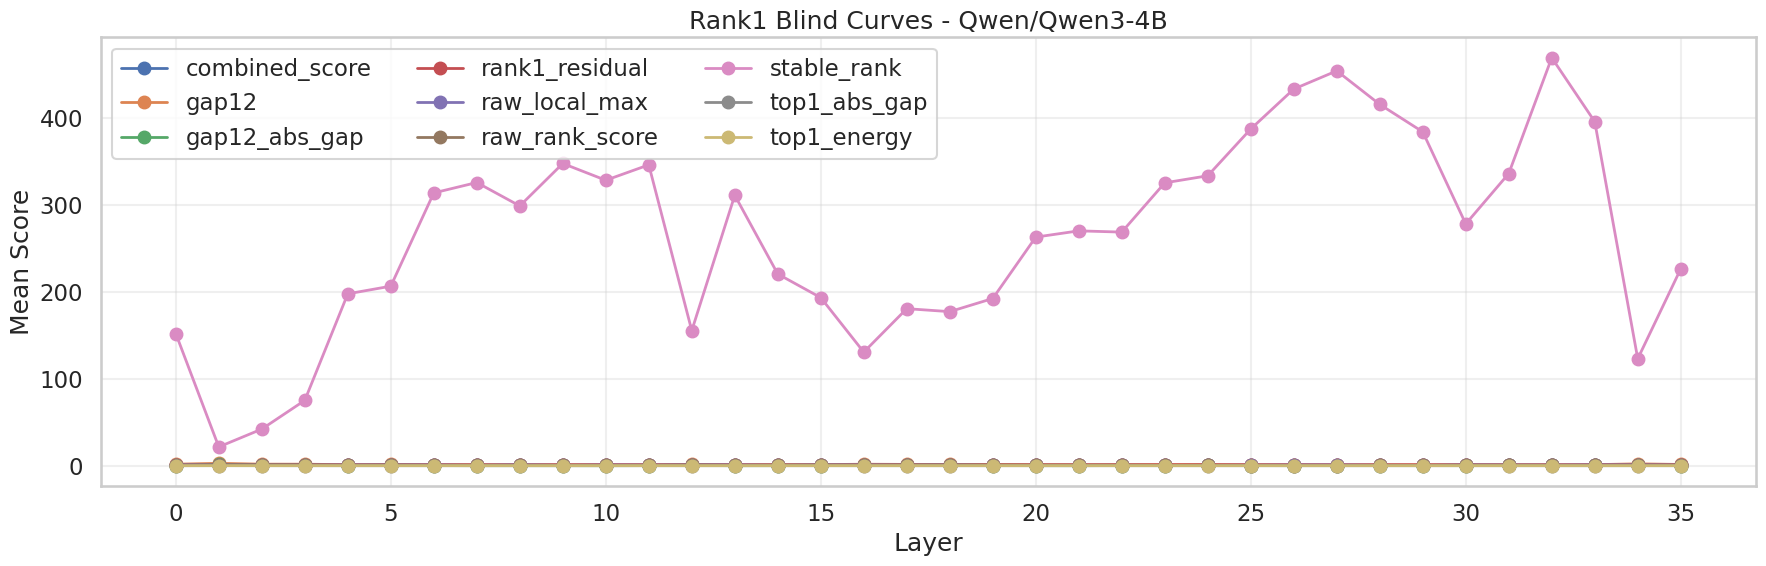

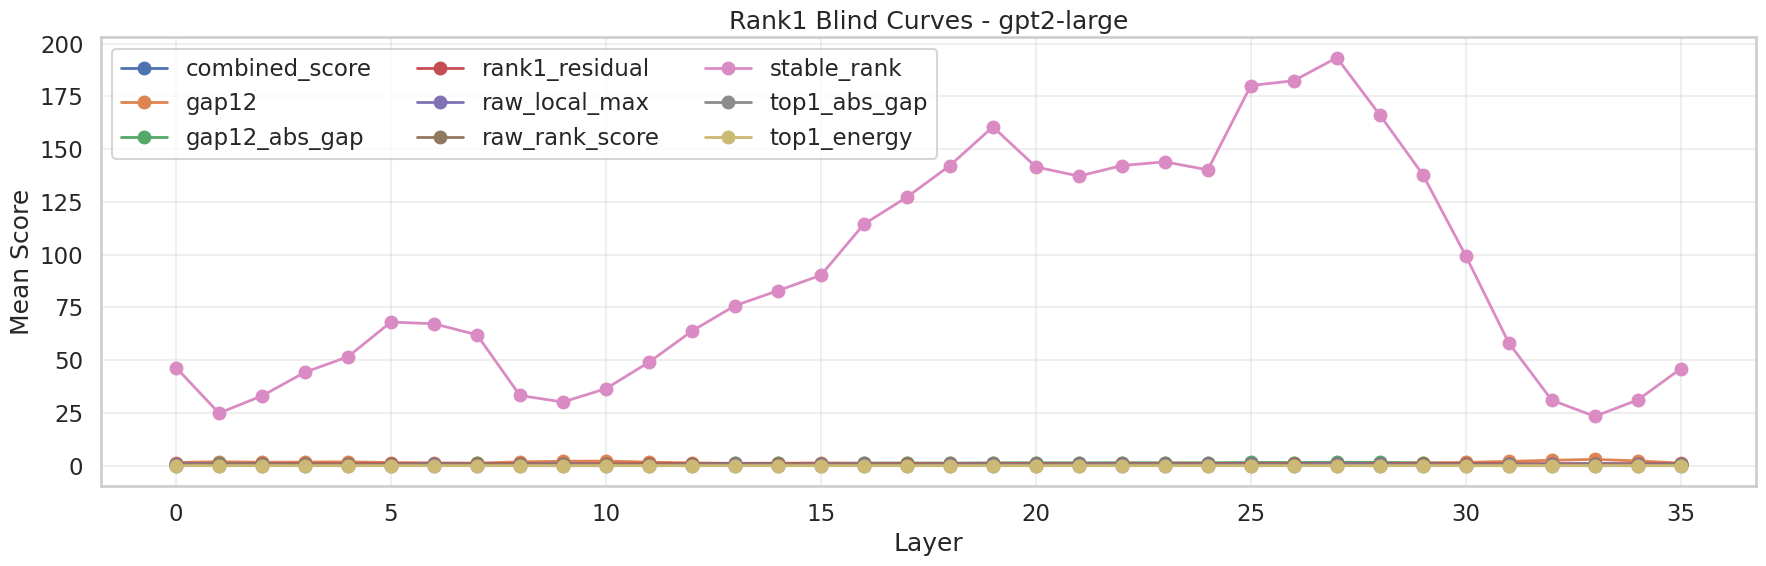

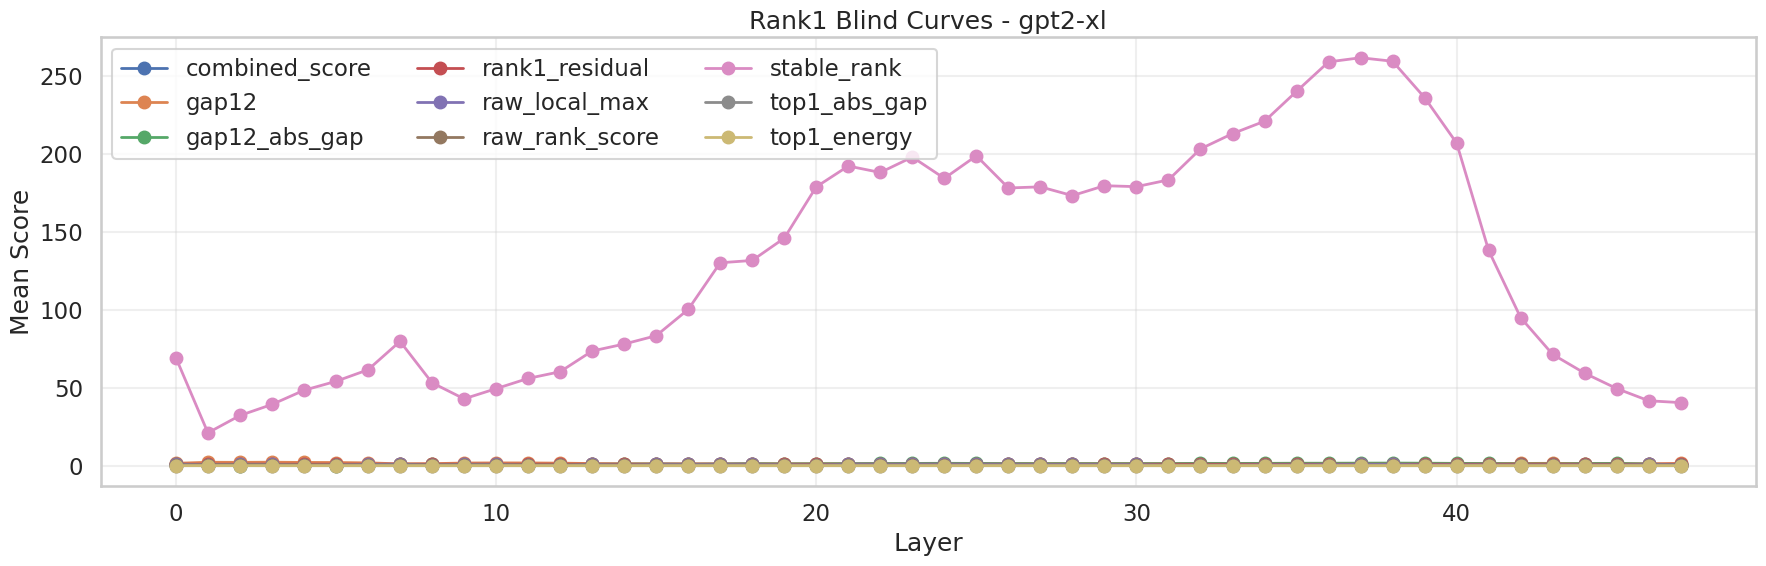

In [6]:
if not rank1_df.empty:
    test_df = rank1_df[rank1_df['source'] == 'test'].copy()
    agg = (test_df.groupby(['model', 'metric', 'layer'])['value']
           .mean()
           .reset_index())

    for model in sorted(agg['model'].unique()):
        plt.figure(figsize=(18, 6))
        sub = agg[agg['model'] == model]
        for metric in sorted(sub['metric'].unique()):
            line = sub[sub['metric'] == metric]
            plt.plot(line['layer'], line['value'], marker='o', linewidth=2, label=metric)
        plt.title(f'Rank1 Blind Curves - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Mean Score')
        plt.legend(loc='best', ncol=3)
        plt.tight_layout()
        plt.show()

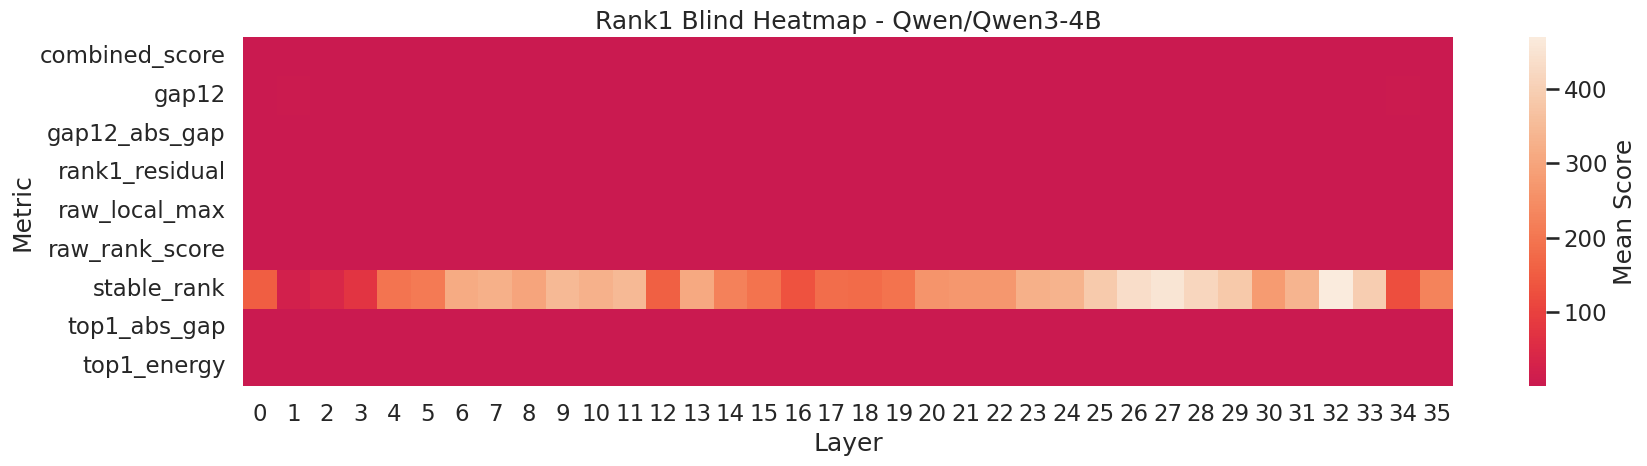

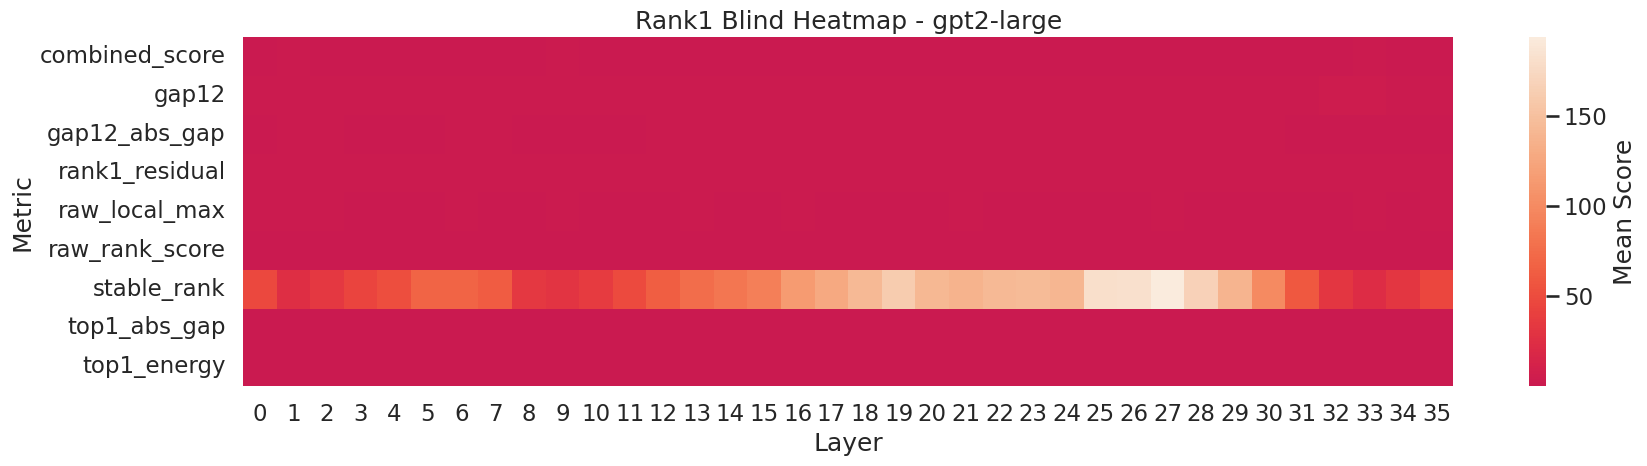

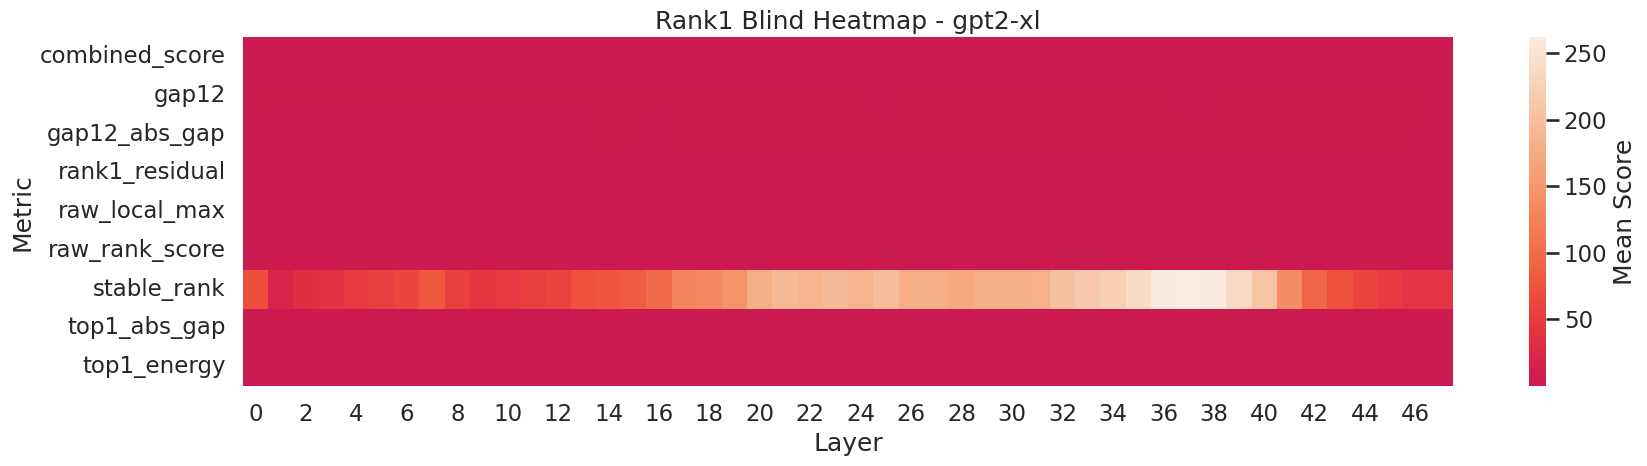

In [7]:
if not rank1_df.empty:
    test_df = rank1_df[rank1_df['source'] == 'test']
    for model in sorted(test_df['model'].unique()):
        pivot = (test_df[test_df['model'] == model]
                 .groupby(['metric', 'layer'])['value']
                 .mean()
                 .unstack(fill_value=np.nan))
        plt.figure(figsize=(18, 5))
        sns.heatmap(pivot, cmap='rocket', center=np.nanmedian(pivot.values), cbar_kws={'label': 'Mean Score'})
        plt.title(f'Rank1 Blind Heatmap - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Metric')
        plt.tight_layout()
        plt.show()

In [8]:
pred_frames = [collect_detection_predictions(p, detection_key='rank1_blind') for p in payloads]
pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

if pred_df.empty:
    print('No prediction rows for rank1_blind detector.')
else:
    pred_df = pred_df.copy()
    pred_df['abs_error'] = (pred_df['predicted_layer'] - pred_df['target_layer']).abs()

    summary = pred_df.groupby('model').agg(
        n=('case_id', 'size'),
        exact_accuracy=('correct', 'mean'),
        hit_at_1=('abs_error', lambda s: (s <= 1).mean()),
        hit_at_2=('abs_error', lambda s: (s <= 2).mean()),
        hit_at_4=('abs_error', lambda s: (s <= 4).mean()),
        mean_abs_error=('abs_error', 'mean'),
        mean_score=('detection_score', 'mean'),
    ).reset_index()

    display(summary)
    display(pred_df.sort_values(['model', 'case_id']).head(30))

,model,n,exact_accuracy,hit_at_1,hit_at_2,hit_at_4,mean_abs_error,mean_score
0,Qwen/Qwen3-4B,806,0.827543,0.827543,0.827543,0.827543,1.724566,0.881144
1,gpt2-large,806,0.009926,0.009926,0.009926,1.000000,2.970223,0.770577
2,gpt2-xl,806,0.009926,0.009926,0.009926,0.009926,15.841191,0.825434


,model,case_id,target_layer,predicted_layer,detection_score,has_prediction,correct,abs_error
2400,Qwen/Qwen3-4B,0,12,12,0.894612,True,True,0
2403,Qwen/Qwen3-4B,0,12,12,0.922224,True,True,0
2401,Qwen/Qwen3-4B,1,12,12,0.901041,True,True,0
2404,Qwen/Qwen3-4B,1,12,12,0.927367,True,True,0
2402,Qwen/Qwen3-4B,2,12,12,0.895898,True,True,0
2405,Qwen/Qwen3-4B,2,12,12,0.907122,True,True,0
0,Qwen/Qwen3-4B,73,12,12,0.919980,True,True,0
100,Qwen/Qwen3-4B,73,12,12,0.927367,True,True,0
200,Qwen/Qwen3-4B,73,12,12,0.919980,True,True,0
300,Qwen/Qwen3-4B,73,12,12,0.919980,True,True,0


In [9]:
if not rank1_df.empty:
    diag = (
        rank1_df[rank1_df['source'] == 'test']
        .groupby('metric')['value']
        .agg(
            n='size',
            min='min',
            max='max',
            mean='mean',
            median='median',
            near_zero=lambda s: float((s.abs() < 1e-10).mean()),
        )
        .reset_index()
        .sort_values('metric')
    )
    display(diag)

    counts = (
        rank1_df[rank1_df['source'] == 'test']
        .groupby(['model', 'metric'])['value']
        .size()
        .reset_index(name='rows')
    )
    display(counts.pivot(index='metric', columns='model', values='rows').fillna(0).astype(int))

,metric,n,min,max,mean,median,near_zero
0,combined_score,96720,0.324714,0.964000,0.598660,0.594301,0.0
1,gap12,96720,1.001430,3.211168,1.375978,1.197535,0.0
2,gap12_abs_gap,96720,0.001097,1.668028,0.782335,0.868182,0.0
3,rank1_residual,96720,0.912604,0.997871,0.988463,0.992972,0.0
4,raw_local_max,96720,0.127660,1.000000,0.673094,0.714286,0.0
5,raw_rank_score,96720,0.114286,0.934286,0.500000,0.508571,0.0
6,stable_rank,96720,11.439000,469.464307,158.852418,142.234039,0.0
7,top1_abs_gap,96720,0.000083,0.051212,0.016189,0.018770,0.0
8,top1_energy,96720,0.002129,0.087396,0.011537,0.007028,0.0


model,Qwen/Qwen3-4B,gpt2-large,gpt2-xl
metric,,,
combined_score,29016,29016,38688
gap12,29016,29016,38688
gap12_abs_gap,29016,29016,38688
rank1_residual,29016,29016,38688
raw_local_max,29016,29016,38688
raw_rank_score,29016,29016,38688
stable_rank,29016,29016,38688
top1_abs_gap,29016,29016,38688
top1_energy,29016,29016,38688
